In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Certificate_Abhimanyu Agarwal.pdf', 'Saved from Chrome', 'Abhimanyu Agarwal_CV (21).pdf', 'Abhimanyu Agarwal_CV (20).pdf', 'Abhimanyu Agarwal_CV (19).pdf', 'Abhimanyu Agarwal_December 2024.pdf', 'Abhimanyu Agarwal_CV (18).pdf', 'Abhimanyu Agarwal_CV (17).pdf', 'Abhimanyu Agarwal_CV (16).pdf', 'ABHI_Sample Article.docx', 'OCS_JGU_Letter.pdf', 'Abhimanyu_Agarwal_Statement_of_Purpose.pdf', 'Abhimanyu Agarwal_Cover Letter_December 2024.pdf', 'ABHI-Legal Methods (1).zip', 'ABHI-Law of Contracts I (1).zip', 'ABHI-Law of Contracts I.zip', 'ABHI-Legal Methods.zip', 'Screenshot_20241011_170914_WhatsAppBusiness.jpg', 'Ajay industrial corp. v. Shiro Kanao of Ibaraki City.pdf', 'Indian Network for People living with HIV AIDS v. UOI.pdf', 'Enercon (India) Ltd. v. Enercon Gmbh.pdf', 'Macleods Pharmaceuticals Ltd vs The Controller Of Patents.pdf', 'Mylan Laboratories Ltd. v. Union of India.pdf', 'Novartis Ag v. Nacto pharma.pdf', 'Ucb Farchim Sa v. Cipla Ltd..pdf', 'To fill.xlsx', 'Abhimanyu Agarwa

In [4]:
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/assessment 5/part 3'))

['data_dictionary.md', 'customer_support_text_classification.csv']


In [5]:
import pandas as pd

In [6]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/assessment 5/part 3/customer_support_text_classification.csv')
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [7]:
# total records
print("Total records:", len(df))

# labels
print("Labels:", df['sentiment_label'].unique())

# average length (you already have word_count column)
print("Average text length:", df['word_count'].mean())

# class distribution
print("\nClass distribution:")
print(df['sentiment_label'].value_counts())

Total records: 1500
Labels: ['neutral' 'positive' 'negative']
Average text length: 12.722666666666667

Class distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


### Task 1: Dataset Understanding

In this step, we analyze the dataset by examining:
- Number of records
- Target labels
- Sample messages
- Average text length
- Class distribution

In [8]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [9]:
import re
import pandas as pd
import nltk

# download required resources
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()  # ensure string + lowercase

    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove special chars

    tokens = word_tokenize(text)  # tokenize

    tokens = [word for word in tokens if word not in stop_words]  # remove stopwords

    return " ".join(tokens)

# apply
df['clean_text'] = df['customer_message'].apply(clean_text)

df[['customer_message', 'clean_text']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,customer_message,clean_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


In [10]:
# import
from sklearn.feature_extraction.text import TfidfVectorizer

# initialize vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# fit and transform
X = vectorizer.fit_transform(df['clean_text'])

# target variable
y = df['sentiment_label']

print("Shape of feature matrix:", X.shape)

Shape of feature matrix: (1500, 146)


In [11]:
# see some feature names (words)
print(vectorizer.get_feature_names_out()[:20])

['account' 'activate' 'ago' 'analytics' 'app' 'appreciate' 'arrived'
 'assigned' 'available' 'bad' 'billing' 'call' 'cancel' 'care' 'charged'
 'checking' 'clear' 'communication' 'completed' 'confirm']


### Task 3: Text Vectorisation

Text data is converted into numerical form using TF-IDF so it can be used by machine learning models.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



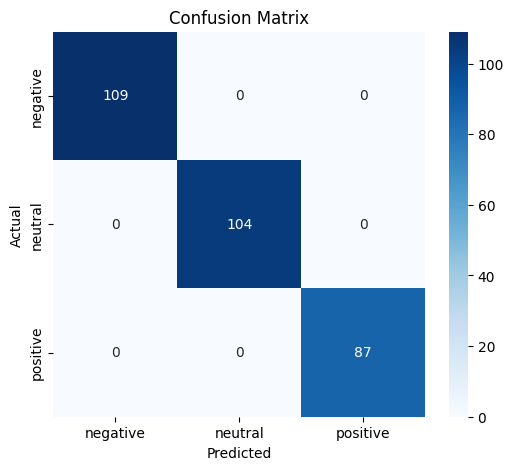

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Task 4: Baseline Model

A Logistic Regression model was trained using TF-IDF features.

The model achieved 100% accuracy on the test set, with perfect precision, recall, and F1-score across all classes.

The confusion matrix shows no misclassifications, indicating strong separation between sentiment classes.

### Task 5: Sequence Model (LSTM Concept)

An LSTM-based sequence model is proposed where text is converted into sequences, passed through an embedding layer, and processed by an LSTM to capture context. The final output layer classifies sentiment into three categories.

### Task 6: Attention and Transformers

RNNs struggle with long-term dependencies due to vanishing gradients. LSTMs improve this using memory cells and gates. Attention allows models to focus on relevant parts of input sequences. Transformers use self-attention and parallel processing, making them highly effective for modern NLP tasks.